# Keypoint-Based Homography Pipeline Demo

This notebook demonstrates the full pipeline:
1. **Keypoint Detection** → Homography matrix (with temporal EMA smoothing)
2. **Team Color Analysis** → K-means jersey color clustering
3. **Perspective Transform** → Player projection onto pitch
4. **Segmentation** → Deep analysis overlay

**New features**:
- Homography EMA smoothing (`SMOOTHING_ALPHA=0.4`) — reduces frame-to-frame jitter
- Team color analysis (K-means on jersey colors) — segregates players into teams
- Team-colored dots + legend on pitch canvas
- Team-colored bounding boxes on annotated frames

Model paths:
- Keypoint: `../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt`
- Player: `../models/player_model/best.pt`
- Segmentation: `../models/segmentation/best.pt`

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

from app.keypoint_pipeline import KeypointPipeline
from app.keypoint_service import PitchKeypointMapper, KeypointHomographyComputer
from app.constants import *
from app.pitch import PitchArtist
from app.director import Director
from app.team_analyzer import TeamColorAnalyzer

%matplotlib inline
print('Imports loaded successfully.')

Imports loaded successfully.


## Configuration

Set your input video and model paths below.

In [2]:
# == USER INPUTS ==
SOURCE_VIDEO_PATH ="../data/test_data/FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025⧸26 MD15 🔵🔴 [93LPZJkCW2w].webm"

# Model paths
KEYPOINT_MODEL_PATH = "../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt"
PLAYER_MODEL_PATH = "../models/player_model/best.pt"
SEG_MODEL_PATH = "../models/segmentation/best.pt"

# Output directory
OUTPUT_DIR = Path("keypoint_demo_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source video: {SOURCE_VIDEO_PATH}")
print(f"Keypoint model: {KEYPOINT_MODEL_PATH}")
print(f"Player model: {PLAYER_MODEL_PATH}")
print(f"Segmentation model: {SEG_MODEL_PATH}")
print(f"Smoothing: alpha={SMOOTHING_ALPHA}, stability threshold={H_STABILITY_THRESHOLD}")
print(f"Team colors: enabled")

Source video: ../data/test_data/FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025⧸26 MD15 🔵🔴 [93LPZJkCW2w].webm
Keypoint model: ../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt
Player model: ../models/player_model/best.pt
Segmentation model: ../models/segmentation/best.pt
Smoothing: alpha=0.4, stability threshold=0.15
Team colors: enabled


## Initialize Pipeline

In [3]:
# Initialize the full pipeline with team colors enabled
pipeline = KeypointPipeline(
    keypoint_model_path=KEYPOINT_MODEL_PATH,
    player_model_path=PLAYER_MODEL_PATH,
    seg_model_path=SEG_MODEL_PATH,
    enable_team_colors=True,  # Enables team color analysis + colored rendering
)

print("Pipeline initialized.")
print(f"  Enable team colors: {pipeline.team_analyzer is not None}")

Pipeline initialized.
  Enable team colors: True


## Test on a Single Frame

Let's process a single frame to verify the pipeline works correctly.

In [13]:
# Open video and grab a frame
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)

# Seek to frame 300 (same as original del.ipynb)
frame_num=300
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)

ret, frame = cap.read()
if not ret:
    raise RuntimeError(f"Could not read frame from {SOURCE_VIDEO_PATH}")

cap.release()

frame_h, frame_w = frame.shape[:2]
print(f"Frame size: {frame_w}x{frame_h}")

Frame size: 1920x1080


### Original Frame

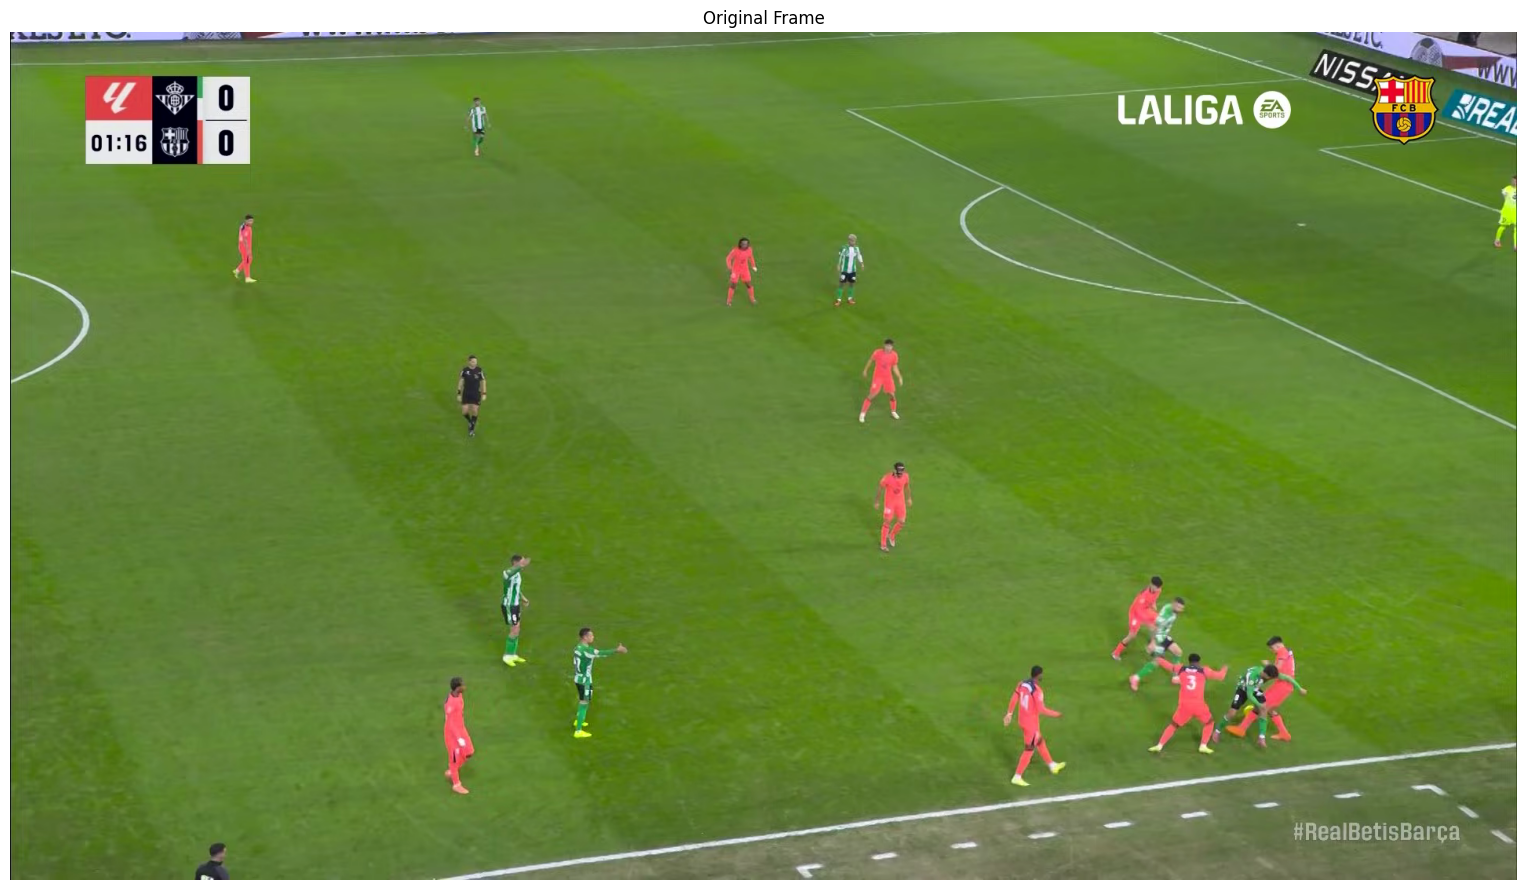

In [14]:
plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('Original Frame')
plt.axis('off')
plt.tight_layout()
plt.show()

### Run Pipeline

This runs the full pipeline on the single test frame.

In [15]:
result = pipeline.process_frame(frame, frame_idx=frame_num)

H = result['H']
H_info = result['H_info']
player_xyxy = result['player_xyxy']
player_conf = result['player_conf']
used_kpts = result['keypoints_used']
player_pitch_pts = result['player_pitch_pts']
team_info = result['team_info']

print(f"Homography mode:   {H_info.get('mode', 'N/A')}")
print(f"Keypoints used:    {len(used_kpts)}")
print(f"Inliers:           {H_info.get('inliers', 0)} / {H_info.get('total_points', 0)}")
print(f"Players detected:  {len(player_pitch_pts)}")

if H is None:
    print("\n⚠️  Could not compute homography on this frame.")
else:
    print("\n✅ Homography computed successfully.")

if team_info is not None and len(team_info.get('team_ids', [])) > 0:
    n_team1 = int((team_info['team_ids'] == 0).sum())
    n_team2 = int((team_info['team_ids'] == 1).sum())
    n_gk = int((team_info['team_ids'] == -1).sum())
    print(f"\n🎨 Teams: Team1={n_team1}, Team2={n_team2}, GK={n_gk}")

NOTHING REMOVED
Homography mode:   keypoint-ransac
Keypoints used:    5
Inliers:           5 / 5
Players detected:  19

✅ Homography computed successfully.

🎨 Teams: Team1=8, Team2=11, GK=0


## Output Visualizations

### 1. Annotated Frame (Keypoints + Team Bboxes + Segmentation Overlay)

The original frame with:
- **Yellow dots**: Keypoints used for homography (with labels)
- **Colored polygons**: Segmentation masks (deep analysis)
- **Team-colored bboxes**: Semi-transparent bounding boxes colored by team

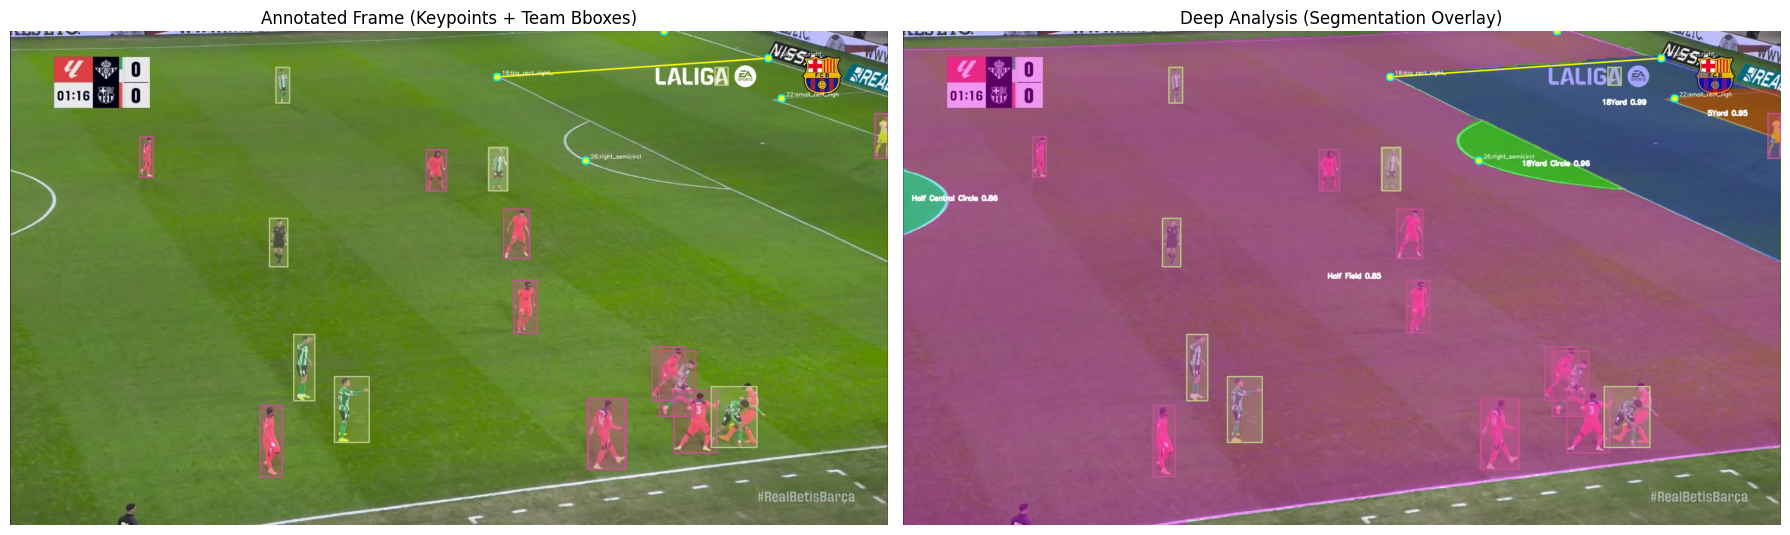

In [16]:
plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
annotated = result['annotated_frame']
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Annotated Frame (Keypoints + Team Bboxes)')
plt.axis('off')

plt.subplot(1, 2, 2)
deep_analysis = result['deep_analysis_frame']
plt.imshow(cv2.cvtColor(deep_analysis, cv2.COLOR_BGR2RGB))
plt.title('Deep Analysis (Segmentation Overlay)')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Top-Down Pitch Canvas (Team-Colored)

Bird's-eye view of the pitch with players projected via the homography.
Players are colored by team. A legend in the top-right shows the team colors.

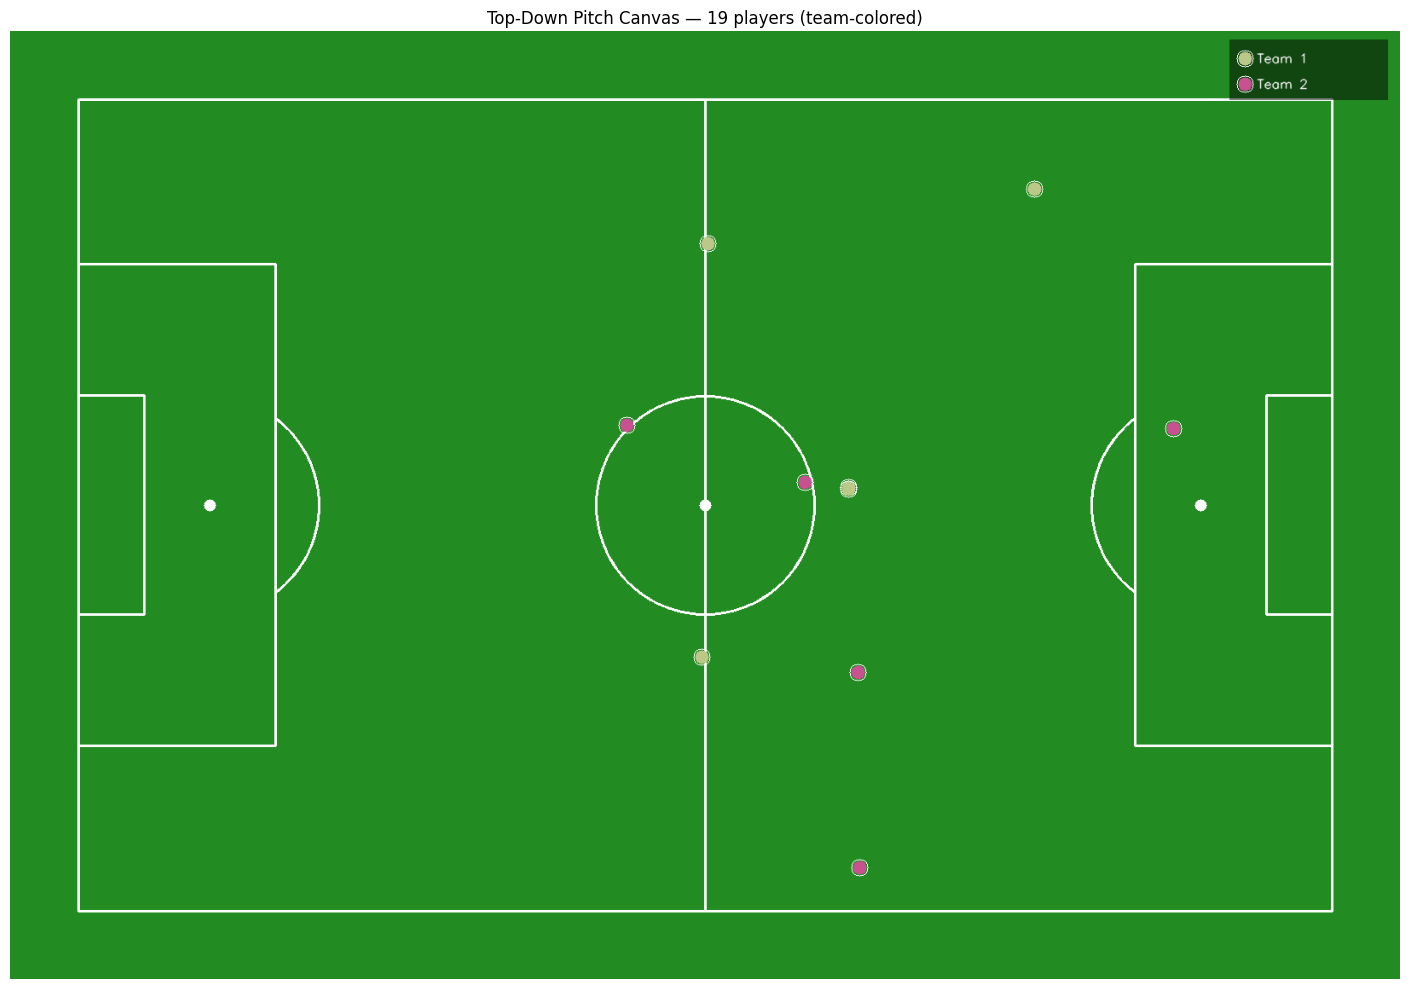

In [17]:
pitch_canvas = result['pitch_canvas']
plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(pitch_canvas, cv2.COLOR_BGR2RGB))
plt.title(f'Top-Down Pitch Canvas — {len(player_pitch_pts)} players (team-colored)')
plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Keypoint Details

List all keypoints used in the homography computation.

In [9]:
print(f"{'ID':<4} {'Name':<30} {'Image (x,y)':<25} {'Pitch (x,y)':<20} {'Conf':<6}")
print('-' * 85)
for kp in used_kpts:
    img_pt = f"({kp['image_pt'][0]:.1f}, {kp['image_pt'][1]:.1f})"
    pitch_pt = f"({kp['pitch_pt'][0]:.2f}, {kp['pitch_pt'][1]:.2f})"
    print(f"{kp['kpt_id']:<4} {kp['name']:<30} {img_pt:<25} {pitch_pt:<20} {kp['confidence']:<6.1f}")

ID   Name                           Image (x,y)               Pitch (x,y)          Conf  
-------------------------------------------------------------------------------------
13   center_circle_top              (1045.4, 302.9)           (52.50, 24.85)       0.5   
14   center_circle_bottom           (1045.1, 492.5)           (52.50, 43.15)       0.6   
27   center_circle_left             (651.4, 389.9)            (43.35, 34.00)       0.4   
28   center_circle_right            (1442.3, 392.8)           (61.65, 34.00)       0.5   


### 4. Team Color Details

Shows the team assignment for each detected player.

In [10]:
if team_info is not None and len(team_info.get('team_ids', [])) > 0:
    team_ids = team_info['team_ids']
    colors = team_info['team_colors']
    print(f"{'#':<4} {'Team':<10} {'BGR Color':<20} {'Conf':<8}")
    print('-' * 42)
    for i in range(min(len(team_ids), len(player_conf))):
        tid = team_ids[i]
        label = 'GK' if tid == -1 else f'Team {tid+1}'
        c = colors[i] if i < len(colors) else (128, 128, 128)
        color_str = f"({int(c[0])}, {int(c[1])}, {int(c[2])})"
        print(f"{i:<4} {label:<10} {color_str:<20} {player_conf[i]:.3f}")
else:
    print("No players detected or team analysis not available.")

#    Team       BGR Color            Conf    
------------------------------------------
0    Team 2     (200, 152, 137)      0.862
1    Team 1     (118, 175, 200)      0.856
2    Team 2     (200, 152, 137)      0.855
3    Team 2     (200, 152, 137)      0.849
4    Team 1     (118, 175, 200)      0.843
5    Team 2     (200, 152, 137)      0.826
6    Team 1     (118, 175, 200)      0.821
7    Team 1     (118, 175, 200)      0.814
8    Team 1     (118, 175, 200)      0.811
9    Team 1     (118, 175, 200)      0.741
10   Team 2     (200, 152, 137)      0.706
11   Team 1     (118, 175, 200)      0.690
12   Team 1     (118, 175, 200)      0.680
13   Team 2     (200, 152, 137)      0.654
14   Team 2     (200, 152, 137)      0.651
15   Team 1     (118, 175, 200)      0.589
16   Team 2     (200, 152, 137)      0.546
17   Team 1     (118, 175, 200)      0.538
18   Team 1     (118, 175, 200)      0.432
19   Team 1     (118, 175, 200)      0.389
20   Team 2     (200, 152, 137)      0.359


## Process Full Video

Process the entire video and generate four output videos:
- `full_pitch_debug_map.mp4` — Top-down pitch view with **team-colored dots + legend** (smoother thanks to EMA homography smoothing)
- `annotated_video.mp4` — Original frame with keypoints + **team-colored bboxes**
- `deep_analysis.mp4` — Original frame with segmentation overlay + **team-colored bboxes**
- `final_draft.mp4` — Original frame with the pitch debug map **overlayed** as a picture-in-picture in the bottom-right corner

In [12]:
# Process a limited number of frames for quick testing
FRAMES_TO_PROCESS = None  # Set to None for all frames
START_FRAME = 0

print(f"Processing {FRAMES_TO_PROCESS or 'all'} frames starting from frame {START_FRAME}...")
print(f"  Smoothing: alpha={SMOOTHING_ALPHA}, stability={H_STABILITY_THRESHOLD}")
print(f"  Team colors: enabled")

for i, frame_result in enumerate(pipeline.process_video(
    source_video_path=SOURCE_VIDEO_PATH,
    output_dir=str(OUTPUT_DIR),
    start_frame=START_FRAME,
    max_frames=FRAMES_TO_PROCESS,
    process_every_n=1,
)):
    pass  # Processing happens in the generator

print("\nVideo processing complete!")

Processing all frames starting from frame 0...
  Smoothing: alpha=0.4, stability=0.15
  Team colors: enabled
Video: 25.0FPS, 1920x1080, 750 frames
Processing from frame 0, max_frames=None
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
  Frame 29: H=fallback-last, kpts=3, players=18
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMO

## Summary

**Pipeline architecture**:
```
Frame → Keypoint Model → 29 keypoints → filter → RANSAC → H matrix
                                                       ↓ EMA smoothing
                                                       ↓ 
Frame → Player Model → bboxes → bottom-center → perspectiveTransform(H) → pitch coords
                       ↓                ↓
              TeamColorAnalyzer    Team-colored dots + bboxes
                (K-means k=2)
                            ↓
Frame → Segmentation Model → masks → overlay on original frame (deep analysis)
```

**New features**:
- `SMOOTHING_ALPHA=0.4` — EMA blend factor for homography smoothing (reduces jitter)
- `H_STABILITY_THRESHOLD=0.15` — Max relative change before rejecting unstable H
- `TeamColorAnalyzer` — K-means (k=2) on jersey colors for team segregation
- Team legend on pitch canvas + team-colored bounding boxes on frames

**Output videos**:
- `full_pitch_debug_map.mp4` — Top-down pitch view with team-colored dots
- `annotated_video.mp4` — Original frame with keypoints + team-colored bboxes
- `deep_analysis.mp4` — Original frame with segmentation overlay + team bboxes
- `final_draft.mp4` — Original frame with pitch debug map overlayed as PIP

**Key files**:
- `app/keypoint_service.py` — `PitchKeypointMapper` + `KeypointHomographyComputer` + `_apply_homography_smoothing()`
- `app/team_analyzer.py` — `TeamColorAnalyzer` (new)
- `app/keypoint_pipeline.py` — `KeypointPipeline` orchestrator (updated)
- `app/pitch.py` — `draw_players_on_pitch()` + `draw_team_legend()` (updated)
- `app/constants.py` — Configuration with smoothing + color analysis constants